<a href="https://colab.research.google.com/github/yawarabbasmalik/Bullying-Words-Classification/blob/main/Bullying_Words_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Basic libraries

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk
import random
import itertools
from collections import defaultdict

# Preprocessing

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from itertools import combinations
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import gensim
from keras.preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from imblearn.under_sampling import NearMiss, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN

# Models

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegressionCV
import lightgbm as lgb

# Evaluation

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, make_scorer
from lime import lime_text
from sklearn.pipeline import make_pipeline
from lime.lime_text import LimeTextExplainer


import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [ ]:
import urduhack
urduhack.download()
from urduhack.normalization import normalize
from urduhack.preprocessing import normalize_whitespace, remove_punctuation, remove_accents, replace_urls, replace_emails, replace_numbers, replace_currency_symbols, remove_english_alphabets

In [ ]:
# Loading Comments Dataset & Skipping Bad Rows Data.

data = pd.read_csv('/content/urdudataset.csv', encoding='utf-8', engine = 'python', error_bad_lines=False)
data.head()

,Review,Label
0,اب دوبارہ کی جانے والی کوالٹی مجھے یہ سوچنے پر...,CAG
1,اب دوبارہ کی جانے والی کوالٹی مجھے یہ سوچنے پر...,CAG
2,کی والدہ کیسی ہیں\nآپ کی بیوی کیسی ہے\nبہن کیس...,NAG
3,یہ بھی دیکھیایساکہ آر ایس ایس کا کارکن برکھا م...,NAG
4,کم کراس فائرنگ میں 2 جوانوں کی موت پر\n\nہمارے...,NAG


In [ ]:
# Total Number of Rows and Columns

data.shape

(3493, 2)

In [ ]:
# check the Null values in both "Review" and "Label" Column

print(data['Label'].isnull().sum())
data['Review'].isnull().sum()

0


0

In [ ]:
# Removing the Duplicate Records

data.drop_duplicates(subset=['Review','Label'],keep='first',inplace=True)
data.shape

(3454, 2)

There exists no null value in both **Reviews** and **Label** Attributes.
However, there are about **39 duplicate** records that we have removed in the above cell of programming query.

In [ ]:
# Confirming the Length of each comment/review and adding the same in the dataframe

data['review_length'] = data['Review'].apply(lambda x: len(x.split(' ')))
data.head()

,Review,Label,review_length
0,اب دوبارہ کی جانے والی کوالٹی مجھے یہ سوچنے پر...,CAG,23
2,کی والدہ کیسی ہیں\nآپ کی بیوی کیسی ہے\nبہن کیس...,NAG,16
3,یہ بھی دیکھیایساکہ آر ایس ایس کا کارکن برکھا م...,NAG,36
4,کم کراس فائرنگ میں 2 جوانوں کی موت پر\n\nہمارے...,NAG,25
5,مودی ہو یا منموہن سنگھ بہنوئی، یہ لوگ صرف ووٹ ...,OAG,15


In [ ]:
#maximum review length present in the dataframe

max(data["review_length"])

510

In [ ]:
#Label Class Count

class_count = data['Label'].value_counts()
class_count

NAG    1415
CAG    1214
OAG     825
Name: Label, dtype: int64

In [ ]:
# Printing the Reviews for comformance of accurate reading of all the data

data.iloc[5]['Review']

'پالیسیوں میں کوئی امتیازی سلوک اور غیر تحفظ پسندی شاید سیکولرزم کی بنیادی باتیں ہیں۔\nسیکولرازم کے جوہر کو سمجھنے کے لیے ذات پات کے مذہب اور برادریوں کی بنیاد پر تحفظات۔'

In [ ]:
# Loading the Gensim Framework for Word2Vec
import gensim.downloader as api
import gensim
word2vec = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


# Data Transformation

In [ ]:
# Text preparation

def basic_preprocessing(df):

    df_temp = df.copy(deep = True)

    df_temp = df_temp.rename(index = str, columns = {'Review': 'text'})

    df_temp.loc[:, 'text'] = [text_prepare(x) for x in df_temp['text'].values]

    le = LabelEncoder()
    le.fit(df_temp['Label'])
    df_temp.loc[:, 'class_label'] = le.transform(df_temp['Label'])

    tokenizer = RegexpTokenizer(r'\w+')

    df_temp["tokens"] = df_temp["text"].apply(tokenizer.tokenize)

    return df_temp

def text_prepare(text):

    REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
    BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
    # STOPWORDS = set(stopwords.words('english'))

    # text = text.lower()
    text = REPLACE_BY_SPACE_RE.sub('', text) # replace REPLACE_BY_SPACE_RE symbols by space in text
    text = BAD_SYMBOLS_RE.sub('', text) # delete symbols which are in BAD_SYMBOLS_RE from text
    # words = text.split()
    # i = 0
    # while i < len(words):
    #     if words[i] in STOPWORDS:
    #         words.pop(i)
    #     else:
    #         i += 1
    # text = ' '.join(map(str, words))# delete stopwords from text

    return text

# Introduce evaluation metrics

def get_metrics(y_test, y_predicted):

    precision = precision_score(y_test, y_predicted, average='weighted')

    recall = recall_score(y_test, y_predicted, average='weighted')

    f1 = f1_score(y_test, y_predicted, average='weighted')

    accuracy = accuracy_score(y_test, y_predicted)
    return accuracy, precision, recall, f1

## Bag of Words (BoW)

In [ ]:
def BOW(data):

    df_temp = data.copy(deep = True)
    df_temp = basic_preprocessing(df_temp)

    count_vectorizer = CountVectorizer()
    count_vectorizer.fit(df_temp['text'])

    list_corpus = df_temp["text"].tolist()
    list_labels = df_temp["class_label"].tolist()

    X = count_vectorizer.transform(list_corpus)

    return X, list_labels

## TF/IDF

In [ ]:
def tfidf(data, ngrams = 1):

    df_temp = data.copy(deep = True)
    df_temp = basic_preprocessing(df_temp)

    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, ngrams))
    tfidf_vectorizer.fit(df_temp['text'])

    list_corpus = df_temp["text"].tolist()
    list_labels = df_temp["class_label"].tolist()

    X = tfidf_vectorizer.transform(list_corpus)

    return X, list_labels

## Word2Vec

In [ ]:
def get_average_word2vec(tokens_list, vector, generate_missing=False, k=300):
    if len(tokens_list)<1:
        return np.zeros(k)
    if generate_missing:
        vectorized = [vector[word] if word in vector else np.random.rand(k) for word in tokens_list]
    else:
        vectorized = [vector[word] if word in vector else np.zeros(k) for word in tokens_list]
    length = len(vectorized)
    summed = np.sum(vectorized, axis=0)
    averaged = np.divide(summed, length)
    return averaged

def get_word2vec_embeddings(vectors, clean_questions, generate_missing=False):
    embeddings = clean_questions['tokens'].apply(lambda x: get_average_word2vec(x, vectors,
                                                                                generate_missing=generate_missing))
    return list(embeddings)

In [ ]:
def w2v(data):

    df_temp = data.copy(deep = True)
    df_temp = basic_preprocessing(df_temp)

    embeddings = get_word2vec_embeddings(word2vec, df_temp)
    list_labels = df_temp["class_label"].tolist()

    return embeddings, list_labels

## Selecting the best model

### Naive Bayes

In [ ]:
def training_naive(X_train_naive, X_test_naive, y_train_naive, y_test_naive, preproc):

    clf = MultinomialNB()
    clf.fit(X_train_naive, y_train_naive)

    res = pd.DataFrame(columns = ['Preprocessing', 'Model', 'Precision', 'Recall', 'F1-score', 'Accuracy'])

    y_pred = clf.predict(X_test_naive)

    f1 = f1_score(y_pred, y_test_naive, average = 'weighted')
    pres = precision_score(y_pred, y_test_naive, average = 'weighted')
    rec = recall_score(y_pred, y_test_naive, average = 'weighted')
    acc = accuracy_score(y_pred, y_test_naive)

    res = res.append({'Preprocessing': preproc, 'Model': 'Naive Bayes', 'Precision': pres,
                     'Recall': rec, 'F1-score': f1, 'Accuracy': acc}, ignore_index = True)

    return res

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def training_rf(X_train_rf, X_test_rf, y_train_rf, y_test_rf, preproc):

    clf = RandomForestClassifier()
    clf.fit(X_train_rf, y_train_rf)

    res = pd.DataFrame(columns = ['Preprocessing', 'Model', 'Precision', 'Recall', 'F1-score', 'Accuracy'])

    y_pred = clf.predict(X_test_rf)

    f1 = f1_score(y_pred, y_test_rf, average = 'weighted')
    pres = precision_score(y_pred, y_test_rf, average = 'weighted')
    rec = recall_score(y_pred, y_test_rf, average = 'weighted')
    acc = accuracy_score(y_pred, y_test_rf)

    res = res.append({'Preprocessing': preproc, 'Model': 'Random Forest', 'Precision': pres,
                     'Recall': rec, 'F1-score': f1, 'Accuracy': acc}, ignore_index = True)

    return res

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

def training_dt(X_train_dt, X_test_dt, y_train_dt, y_test_dt, preproc):

    clf = tree.DecisionTreeClassifier()
    clf.fit(X_train_dt, y_train_dt)

    res = pd.DataFrame(columns = ['Preprocessing', 'Model', 'Precision', 'Recall', 'F1-score', 'Accuracy'])

    y_pred = clf.predict(X_test_dt)

    f1 = f1_score(y_pred, y_test_dt, average = 'weighted')
    pres = precision_score(y_pred, y_test_dt, average = 'weighted')
    rec = recall_score(y_pred, y_test_dt, average = 'weighted')
    acc = accuracy_score(y_pred, y_test_dt)

    res = res.append({'Preprocessing': preproc, 'Model': 'Decision Tree', 'Precision': pres,
                     'Recall': rec, 'F1-score': f1, 'Accuracy': acc}, ignore_index = True)

    return res

### Logistic Regression

In [ ]:
def training_logreg(X_train_log, X_test_log, y_train_log, y_test_log, preproc):

    folds = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 40)

    clf = LogisticRegressionCV(cv = folds, solver = 'saga', multi_class = 'multinomial', n_jobs = -1)

    clf.fit(X_train_log, y_train_log)

    res = pd.DataFrame(columns = ['Preprocessing', 'Model', 'Precision', 'Recall', 'F1-score', 'Accuracy'])

    y_pred = clf.predict(X_test_log)

    f1 = f1_score(y_pred, y_test_log, average = 'weighted')
    pres = precision_score(y_pred, y_test_log, average = 'weighted')
    rec = recall_score(y_pred, y_test_log, average = 'weighted')
    acc = accuracy_score(y_pred, y_test_log)

    res = res.append({'Preprocessing': preproc, 'Model': f'Logistic Regression', 'Precision': pres,
                     'Recall': rec, 'F1-score': f1, 'Accuracy': acc}, ignore_index = True)

    return res

### Light GB

In [ ]:
def training_lgbm(X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm, preproc,
                 n = 120, depth = 4, child = 2, bag = 0.9, feature = 0.9, l1 = 1, l = 0.01, w2v = False):

    if w2v:
        d_train = lgb.Dataset(X_train_lgbm, label=y_train_lgbm)
    else:
        d_train = lgb.Dataset(X_train_lgbm.astype(np.float32), label=y_train_lgbm)

    early_stop = 500
    verbose_eval = False
    num_rounds = n

    params = {
        'objective': 'multiclass',
        'num_class': len(set(y_train_lgbm)),
        'boosting': 'gbdt',
        'metric': 'multi_logloss',
        'max_depth': depth,
        'max_bin': 22,
        'bagging_fraction': bag,
        'feature_fraction': feature,
        'min_child_samples': child,
        'min_child_weight': 1,
        'learning_rate': l,
        'verbosity': -1,
        'data_random_seed': 17,
        'lambda_l1': l1}

    model = lgb.train(params, train_set = d_train, num_boost_round = num_rounds)

    y_pred_proba = model.predict(X_test_lgbm.astype(np.float32), num_iteration=model.best_iteration)
    y_pred = [np.argmax(x) for x in y_pred_proba]

    res = pd.DataFrame(columns = ['Preprocessing', 'Model', 'Precision', 'Recall', 'F1-score', 'Accuracy'])

    f1 = f1_score(y_pred, y_test_lgbm, average = 'weighted')
    pres = precision_score(y_pred, y_test_lgbm, average = 'weighted')
    rec = recall_score(y_pred, y_test_lgbm, average = 'weighted')
    acc = accuracy_score(y_pred, y_test_lgbm)

    res = res.append({'Preprocessing': preproc, 'Model': 'LightGBM', 'Precision': pres,
                     'Recall': rec, 'F1-score': f1, 'Accuracy': acc}, ignore_index = True)

    return res

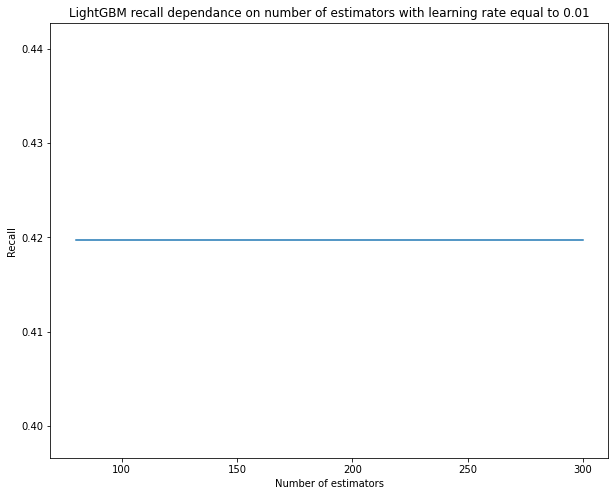

In [ ]:
# Tune number of estimator at learning rate = 0.01

X, y = BOW(data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
ns = range(80, 301, 20)
recalls = []
for n in ns:
    recalls.append(training_lgbm(X_train, X_test, y_train, y_test, 'Count', n = n, l = 0.01)['Recall'].values[0])
fig = plt.figure(figsize = (10, 8))
plt.plot(ns, recalls, label = 'Recall')
plt.xlabel('Number of estimators')
plt.ylabel('Recall')
plt.title('LightGBM recall dependance on number of estimators with learning rate equal to 0.01')
plt.show()

In [ ]:
# Tune maximum tree depth and minimum elements in leaf

depths = range(2, 7, 2)
childs = range(2, 7, 2)
recalls = []
for depth in depths:
    for child in childs:
        recalls.append([training_lgbm(X_train, X_test, y_train, y_test, 'TF-IDF 1-gram',
                                     n = 120, l = 0.01, depth = depth, child = child)['Recall'].values[0], depth, child])
recalls.sort(reverse = True)
recalls[:3]

[[0.4196816208393632, 6, 6],
 [0.4196816208393632, 6, 4],
 [0.4196816208393632, 6, 2]]

## Calculations

In [ ]:
# DataFrame for result evaluation

full_result = pd.DataFrame(columns = ['Preprocessing', 'Model', 'Precision', 'Recall', 'F1-score', 'Accuracy'])

# Testing Count Vectorizer

X, y = BOW(data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
full_result = full_result.append(training_naive(X_train, X_test, y_train, y_test, 'Count Vectorize'), ignore_index = True)
full_result = full_result.append(training_rf(X_train, X_test, y_train, y_test, 'Count Vectorize'), ignore_index = True)
full_result = full_result.append(training_dt(X_train, X_test, y_train, y_test, 'Count Vectorize'), ignore_index = True)
full_result = full_result.append(training_logreg(X_train, X_test, y_train, y_test, 'Count Vectorize'), ignore_index = True)
full_result = full_result.append(training_lgbm(X_train, X_test, y_train, y_test, 'Count Vectorize'), ignore_index = True)

# Testing TF-IDF with 1-gram

X, y = tfidf(data, ngrams = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
full_result = full_result.append(training_naive(X_train, X_test, y_train, y_test, 'TF-IDF 1-grams'), ignore_index = True)
full_result = full_result.append(training_rf(X_train, X_test, y_train, y_test, 'TF-IDF 1-grams'), ignore_index = True)
full_result = full_result.append(training_dt(X_train, X_test, y_train, y_test, 'TF-IDF 1-grams'), ignore_index = True)
full_result = full_result.append(training_logreg(X_train, X_test, y_train, y_test, 'TF-IDF 1-grams'), ignore_index = True)
full_result = full_result.append(training_lgbm(X_train, X_test, y_train, y_test, 'TF-IDF 1-grams'), ignore_index = True)

# Testing TF-IDF with 2-gram

X, y = tfidf(data, ngrams = 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
full_result = full_result.append(training_naive(X_train, X_test, y_train, y_test, 'TF-IDF 2-grams'), ignore_index = True)
full_result = full_result.append(training_rf(X_train, X_test, y_train, y_test, 'TF-IDF 2-grams'), ignore_index = True)
full_result = full_result.append(training_dt(X_train, X_test, y_train, y_test, 'TF-IDF 2-grams'), ignore_index = True)
full_result = full_result.append(training_logreg(X_train, X_test, y_train, y_test, 'TF-IDF 2-grams'), ignore_index = True)
full_result = full_result.append(training_lgbm(X_train, X_test, y_train, y_test, 'TF-IDF 2-grams'), ignore_index = True)

# Testing Word2vec

# X, y = w2v(data)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
# full_result = full_result.append(training_logreg(X_train, X_test, y_train, y_test, 'Word2vec'), ignore_index = True)

full_result


,Preprocessing,Model,Precision,Recall,F1-score,Accuracy
0,Count Vectorize,Naive Bayes,0.995696,0.422576,0.590547,0.422576
1,Count Vectorize,Random Forest,1.000000,0.419682,0.591233,0.419682
2,Count Vectorize,Decision Tree,1.000000,0.419682,0.591233,0.419682
3,Count Vectorize,Logistic Regression,1.000000,0.419682,0.591233,0.419682
4,Count Vectorize,LightGBM,1.000000,0.419682,0.591233,0.419682
5,TF-IDF 1-grams,Naive Bayes,1.000000,0.419682,0.591233,0.419682
6,TF-IDF 1-grams,Random Forest,1.000000,0.419682,0.591233,0.419682
7,TF-IDF 1-grams,Decision Tree,1.000000,0.419682,0.591233,0.419682
8,TF-IDF 1-grams,Logistic Regression,1.000000,0.419682,0.591233,0.419682
9,TF-IDF 1-grams,LightGBM,1.000000,0.419682,0.591233,0.419682


## Best Model Analysis

In [ ]:
# Re-setup the algorithm

X, y = w2v(data)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y, test_size=0.2, random_state=40)
folds = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 40)
clf_w2v = LogisticRegressionCV(cv = folds, solver = 'saga', multi_class = 'multinomial', n_jobs = -1)
clf_w2v.fit(X_train_log, y_train_log)
y_pred = clf_w2v.predict(X_test_log)

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.winter):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=20)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=10, rotation = 90)
    plt.yticks(tick_marks, classes, fontsize=10)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] < thresh else "black", fontsize=12)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=20)
    plt.xlabel('Predicted label', fontsize=20)

    return plt

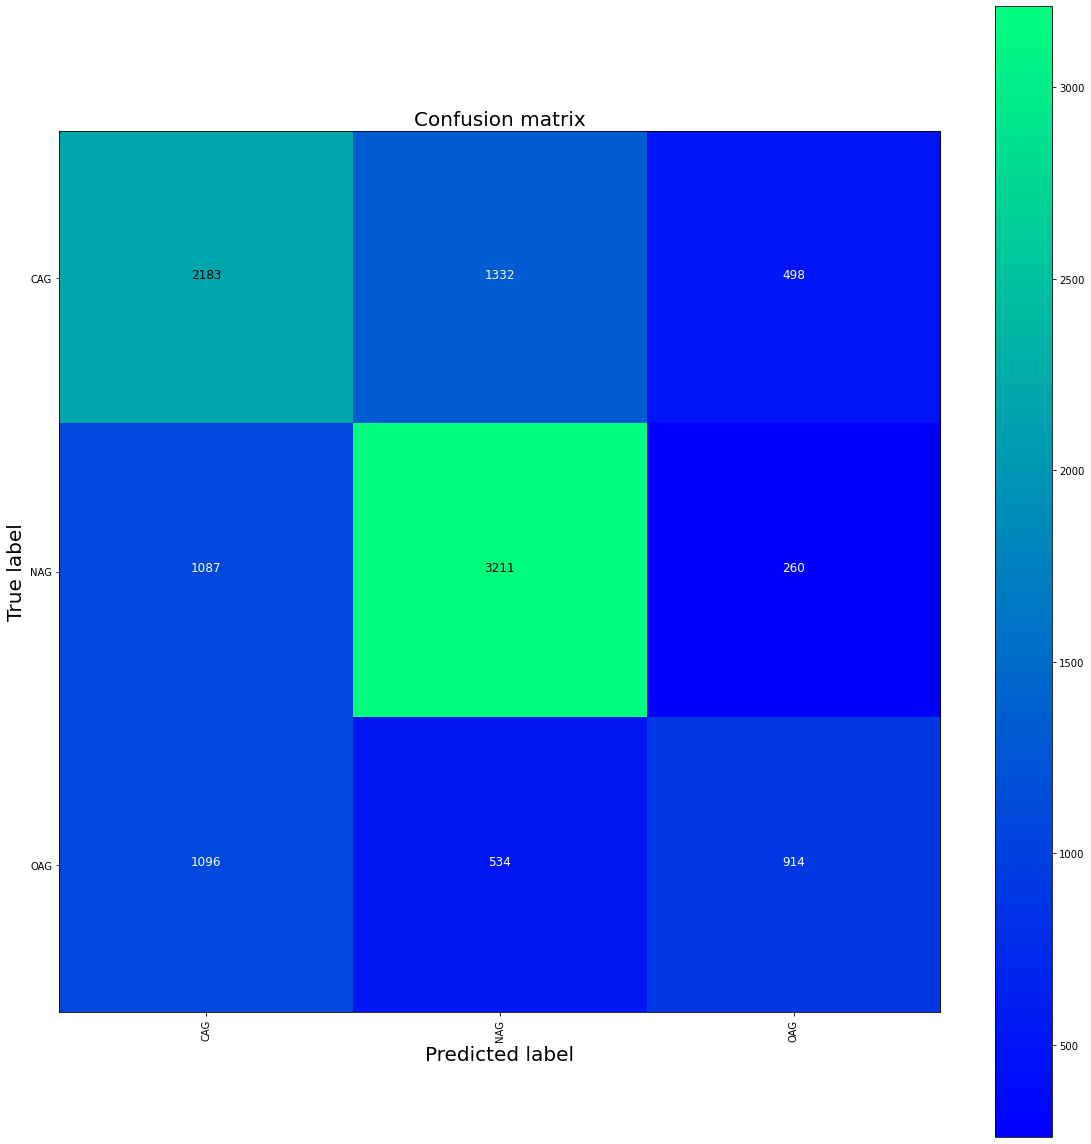

In [ ]:
classes = ['CAG', 'NAG', 'OAG']
cm = confusion_matrix(y_test_log, y_pred)
fig = plt.figure(figsize=(16, 16))
plot = plot_confusion_matrix(cm, classes=classes, normalize=False,
                             title='Confusion matrix')
plt.show()

